# Unsupervised Learning on Country Data
## Customer Intelligence & Country Segmentation

**Dataset:** [Kaggle — Unsupervised Learning on Country Data](https://www.kaggle.com/datasets/rohan0301/unsupervised-learning-on-country-data)

### Overview
This notebook applies unsupervised and supervised machine learning to segment 167 countries based on socio-economic and health indicators. The goal is to identify which countries are most in need of humanitarian aid, which are still developing, and which are already well-established economies.

Techniques used:
- Exploratory Data Analysis — distributions, correlations, outlier detection
- Feature scaling with StandardScaler
- K-Means Clustering with Elbow and Silhouette analysis
- DBSCAN for density-based clustering and outlier flagging
- PCA for 2D visualization of clusters
- Random Forest and XGBoost classifiers to validate cluster separability and rank feature importance


## 1. Install & Import Libraries


In [1]:
# Install required libraries
!pip install -q pandas numpy matplotlib seaborn scikit-learn xgboost


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.inspection import permutation_importance

import xgboost as xgb

# Plot settings
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.2f}'.format)


## 2. Load the Dataset

In [3]:
# Load data — update path if needed
df = pd.read_csv('Country-data.csv')
dict_df = pd.read_csv('data-dictionary.csv')

print(f"Dataset shape: {df.shape[0]} countries × {df.shape[1]} features")
print()
print("Data Dictionary:")
display(dict_df)

Dataset shape: 167 countries × 10 features

Data Dictionary:


,Column Name,Description
0,country,Name of the country
1,child_mort,Death of children under 5 years of age per 100...
2,exports,Exports of goods and services per capita. Give...
3,health,Total health spending per capita. Given as %ag...
4,imports,Imports of goods and services per capita. Give...
5,Income,Net income per person
6,Inflation,The measurement of the annual growth rate of t...
7,life_expec,The average number of years a new born child w...
8,total_fer,The number of children that would be born to e...
9,gdpp,The GDP per capita. Calculated as the Total GD...


In [4]:
display(df.head(10))

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.20,10.00,7.58,44.90,1610,9.44,56.20,5.82,553
1,Albania,16.60,28.00,6.55,48.60,9930,4.49,76.30,1.65,4090
2,Algeria,27.30,38.40,4.17,31.40,12900,16.10,76.50,2.89,4460
3,Angola,119.00,62.30,2.85,42.90,5900,22.40,60.10,6.16,3530
4,Antigua and Barbuda,10.30,45.50,6.03,58.90,19100,1.44,76.80,2.13,12200
5,Argentina,14.50,18.90,8.10,16.00,18700,20.90,75.80,2.37,10300
6,Armenia,18.10,20.80,4.40,45.30,6700,7.77,73.30,1.69,3220
7,Australia,4.80,19.80,8.73,20.90,41400,1.16,82.00,1.93,51900
8,Austria,4.30,51.30,11.00,47.80,43200,0.87,80.50,1.44,46900
9,Azerbaijan,39.20,54.30,5.88,20.70,16000,13.80,69.10,1.92,5840


## 3. Exploratory Data Analysis
Checking data quality, distributions, and relationships before modelling.


In [5]:
# Basic info
print("Shape:", df.shape)
print()
print("Data Types:")
print(df.dtypes)
print()
print("Missing Values:")
print(df.isnull().sum())
print()
print("Duplicate Rows:", df.duplicated().sum())

Shape: (167, 10)

Data Types:
country           str
child_mort    float64
exports       float64
health        float64
imports       float64
income          int64
inflation     float64
life_expec    float64
total_fer     float64
gdpp            int64
dtype: object

Missing Values:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Duplicate Rows: 0


The dataset has 167 countries and 9 numeric features with no missing values and no duplicates. All columns are numeric except `country`, so no encoding is needed.

In [6]:
# Statistical summary
display(df.describe().T.style.background_gradient(cmap='YlOrRd', axis=0))

,count,mean,std,min,25%,50%,75%,max
child_mort,167.000000,38.270060,40.328931,2.600000,8.250000,19.300000,62.100000,208.000000
exports,167.000000,41.108976,27.412010,0.109000,23.800000,35.000000,51.350000,200.000000
health,167.000000,6.815689,2.746837,1.810000,4.920000,6.320000,8.600000,17.900000
imports,167.000000,46.890215,24.209589,0.065900,30.200000,43.300000,58.750000,174.000000
income,167.000000,17144.688623,19278.067698,609.000000,3355.000000,9960.000000,22800.000000,125000.000000
inflation,167.000000,7.781832,10.570704,-4.210000,1.810000,5.390000,10.750000,104.000000
life_expec,167.000000,70.555689,8.893172,32.100000,65.300000,73.100000,76.800000,82.800000
total_fer,167.000000,2.947964,1.513848,1.150000,1.795000,2.410000,3.880000,7.490000
gdpp,167.000000,12964.155689,18328.704809,231.000000,1330.000000,4660.000000,14050.000000,105000.000000


Looking at the summary stats, the features are on very different scales — `gdpp` ranges from ~$231 to ~$105,000 while `health` sits between 1.8 and 17.9. This confirms we need to scale before clustering, otherwise high-magnitude features like `income` and `gdpp` will dominate the distance calculations.

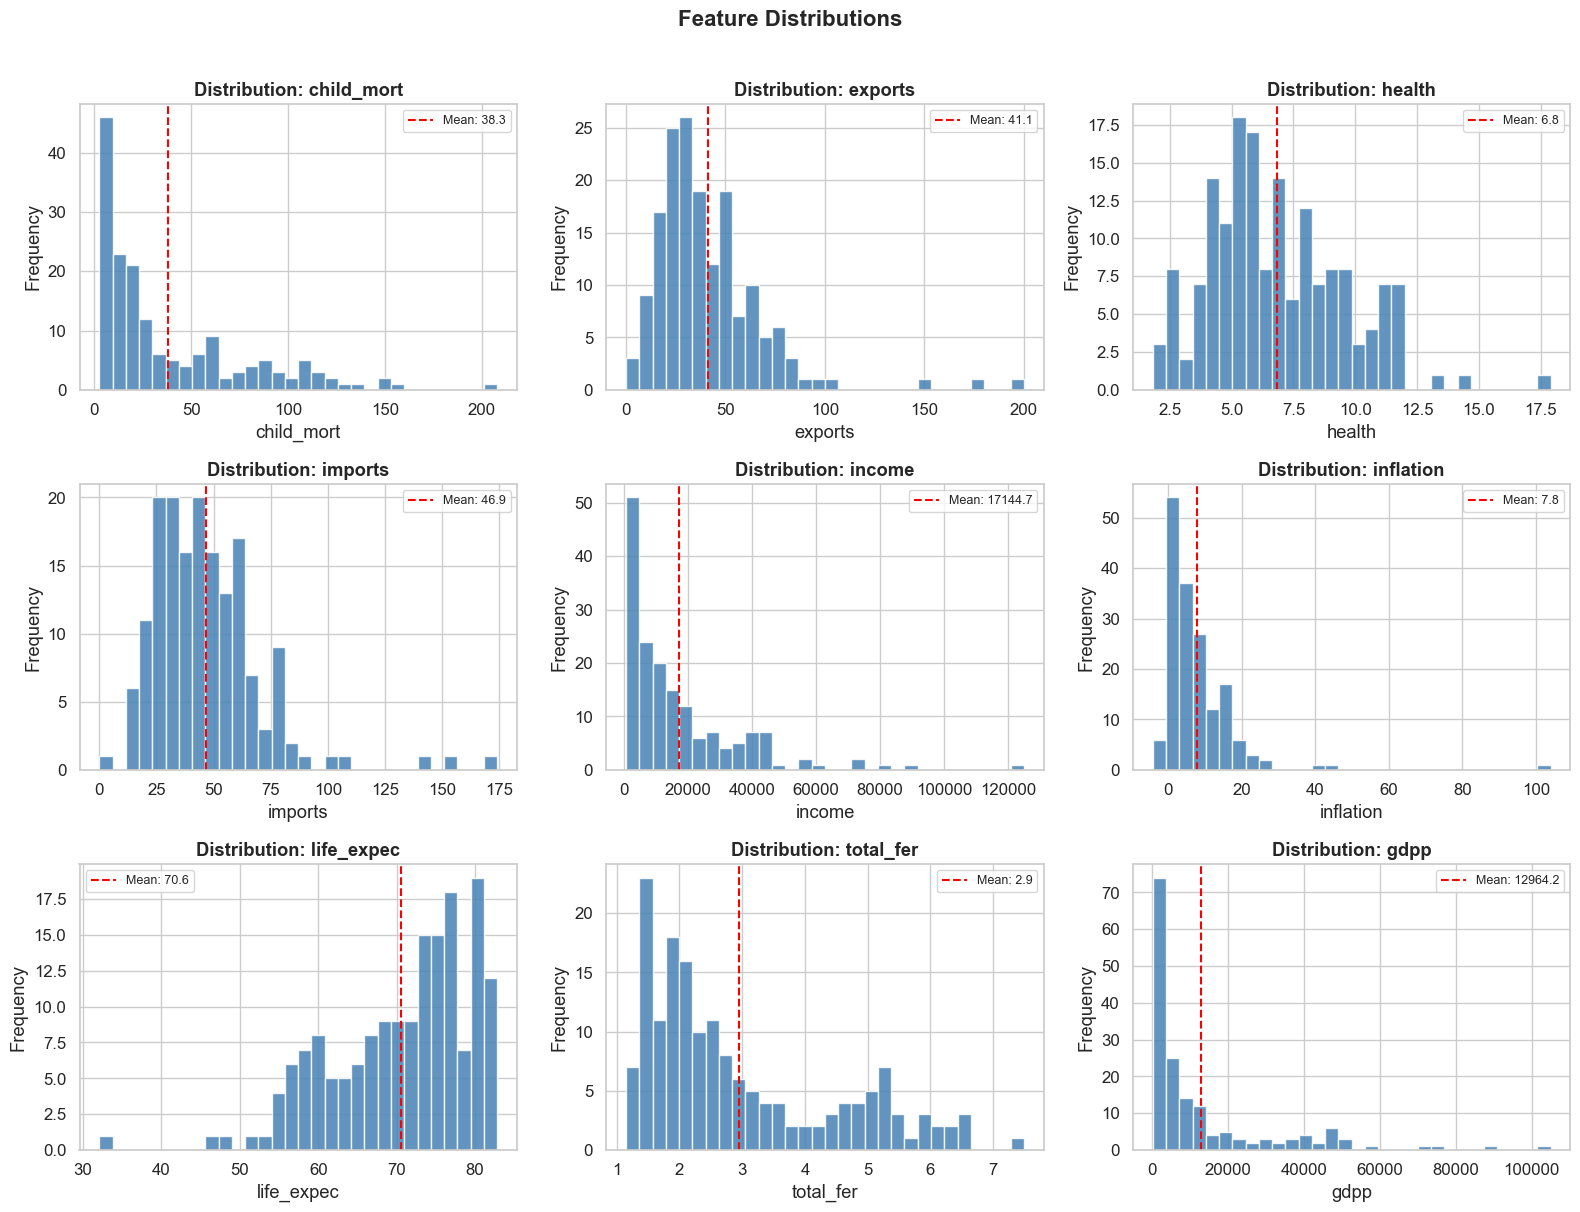

In [7]:
# Distribution plots for all numeric features
numeric_cols = [c for c in df.columns if c != 'country']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Distribution: {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    mean_val = df[col].mean()
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.1f}')
    axes[i].legend(fontsize=9)

plt.suptitle('Feature Distributions', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Most features are right-skewed — a small number of very high-income or high-GDP countries pull the distributions to the right. `child_mort` and `total_fer` show a similar pattern: the majority of countries cluster at lower values but there is a long tail of countries with very high child mortality and fertility rates.

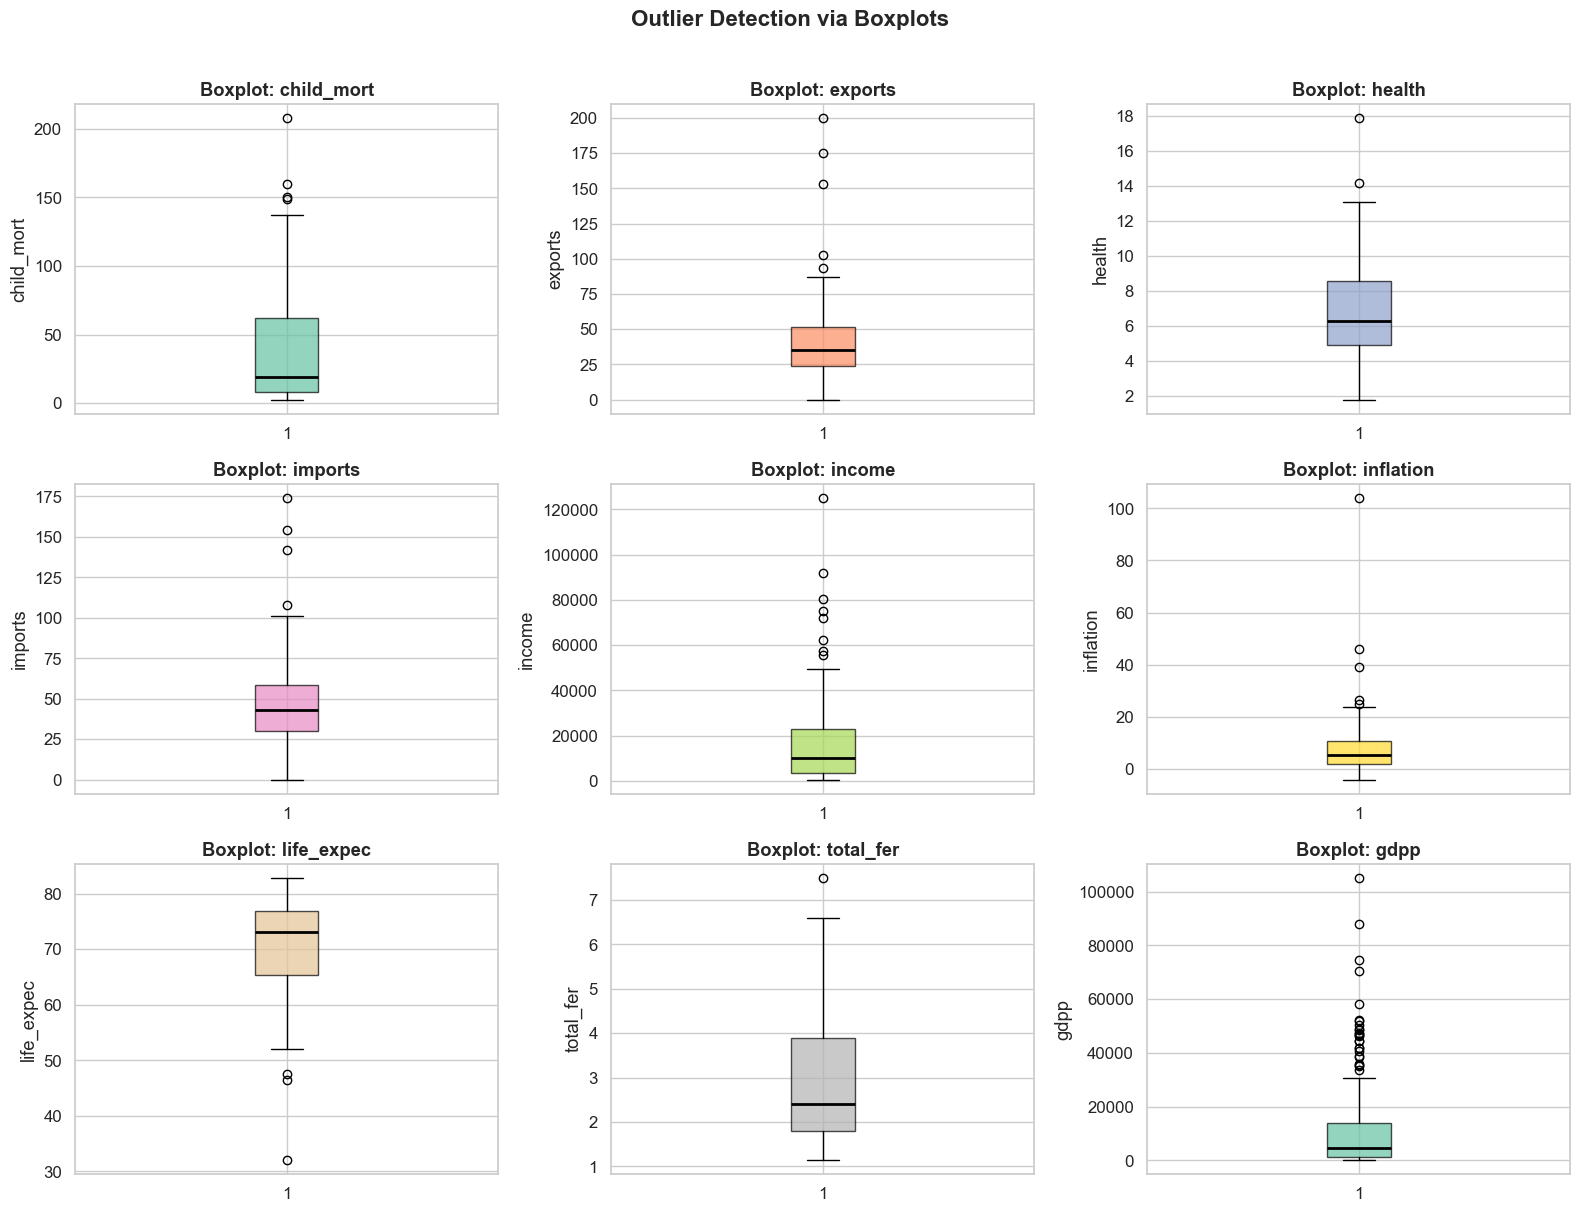

In [8]:
# Boxplots to detect outliers
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

colors = sns.color_palette('Set2', len(numeric_cols))

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor=colors[i], alpha=0.7),
                    medianprops=dict(color='black', linewidth=2))
    axes[i].set_title(f'Boxplot: {col}', fontweight='bold')
    axes[i].set_ylabel(col)

plt.suptitle('Outlier Detection via Boxplots', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

`income` and `gdpp` have the most extreme outliers — a handful of very wealthy nations sit far above the rest. `child_mort` also has a wide spread with several countries above 150 per 1000, which is extreme even within the high-mortality group. These outliers are real data points (not errors) so we keep them — they are exactly what the clustering should separate.

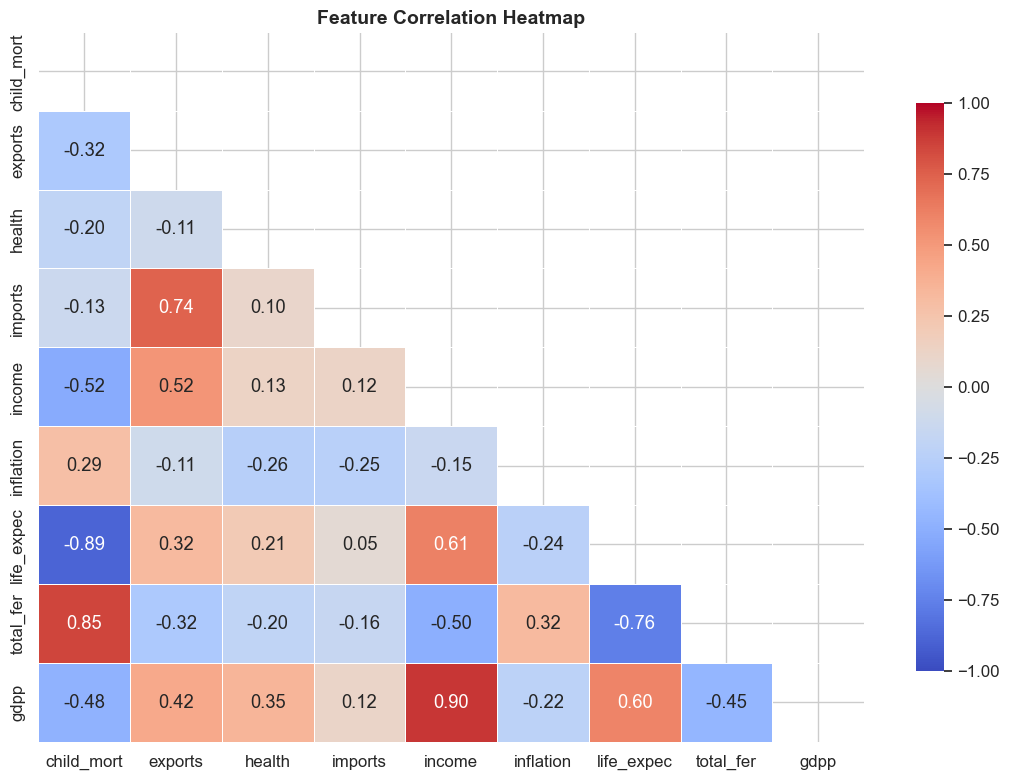


Notable correlations:
  child_mort and total_fer: strong positive — countries with high fertility tend to have high child mortality
  child_mort and life_expec: strong negative — as expected, high mortality means lower life expectancy
  income and gdpp: strong positive — GDP per capita closely tracks income per person


In [9]:
# Correlation heatmap
plt.figure(figsize=(11, 8))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, vmin=-1, vmax=1,
            cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nNotable correlations:")
print("  child_mort and total_fer: strong positive — countries with high fertility tend to have high child mortality")
print("  child_mort and life_expec: strong negative — as expected, high mortality means lower life expectancy")
print("  income and gdpp: strong positive — GDP per capita closely tracks income per person")

The strongest correlations:

- `child_mort` and `life_expec`: **-0.89** — countries with high child mortality almost always have low life expectancy
- `child_mort` and `total_fer`: **+0.85** — high fertility tracks closely with high child mortality
- `income` and `gdpp`: **+0.97** — these two features are nearly interchangeable

The high collinearity between `income` and `gdpp` means they carry similar information. Both are kept since StandardScaler handles the scale difference, but it is worth noting that one largely redundant feature won't hurt clustering — it just adds a little weight to that dimension.

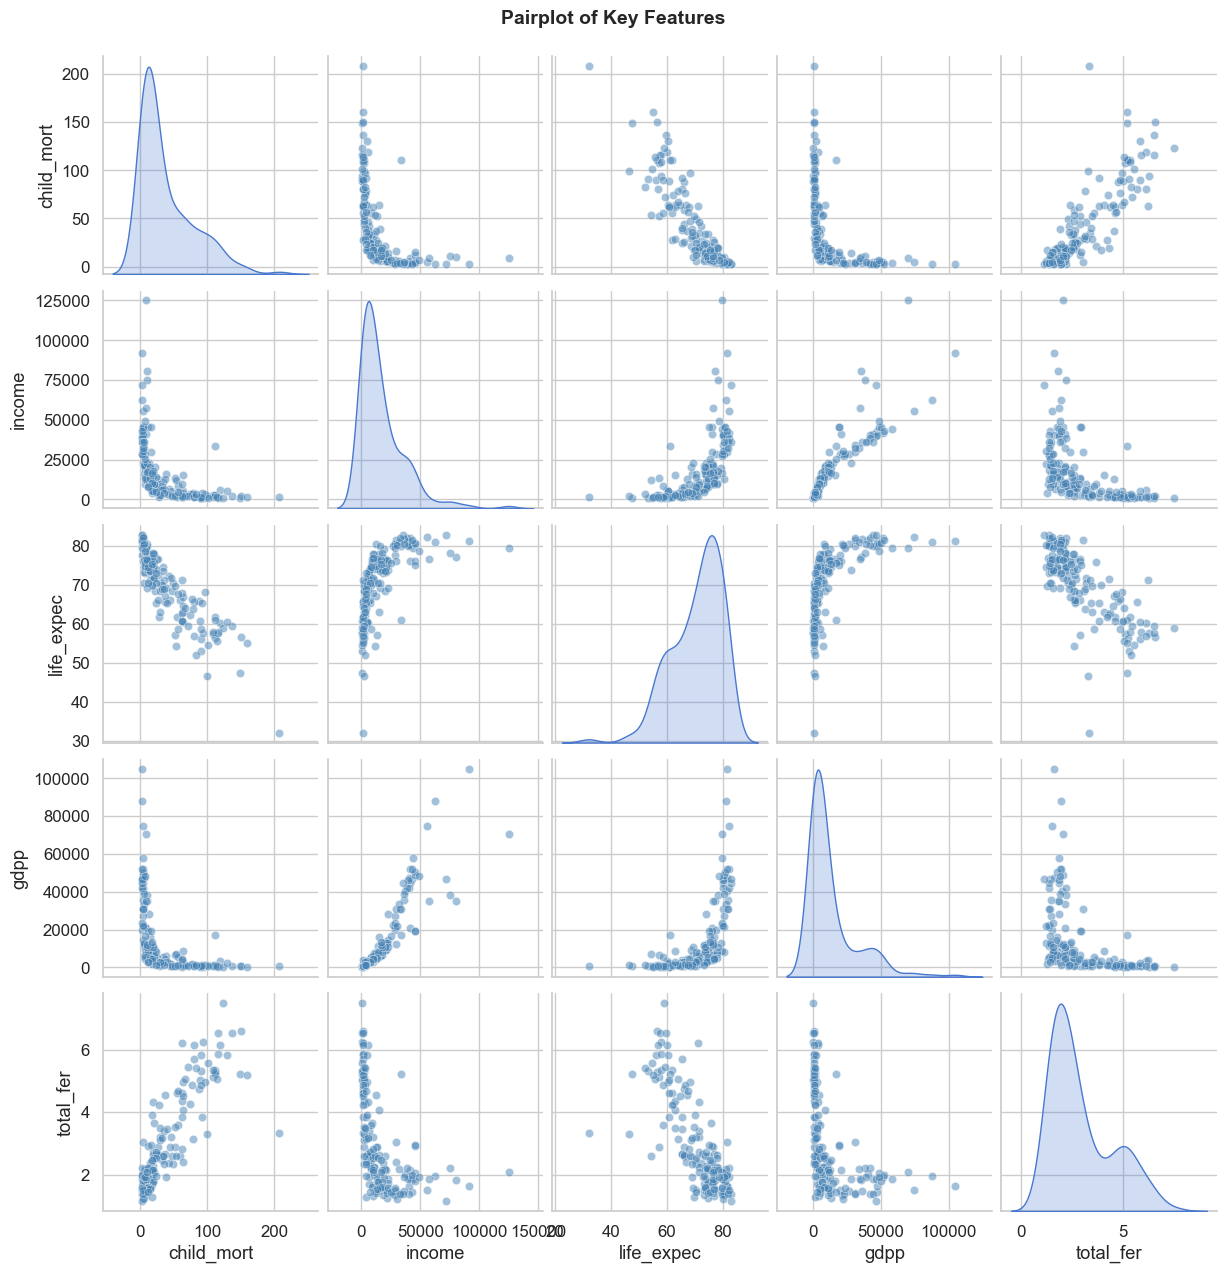

In [10]:
# Pairplot for key features
key_features = ['child_mort', 'income', 'life_expec', 'gdpp', 'total_fer']
sns.pairplot(df[key_features], diag_kind='kde', plot_kws={'alpha': 0.5, 'color': 'steelblue'})
plt.suptitle('Pairplot of Key Features', y=1.02, fontsize=14, fontweight='bold')
plt.show()

## 4. Data Preprocessing & Feature Scaling
Clustering is distance-based so all features need to be on the same scale before fitting.


In [11]:
# Clean and copy
df_clean = df.copy()
df_clean.columns = [c.strip().lower() for c in df_clean.columns]
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

# Ensure numeric types
numeric_cols = [c for c in df_clean.columns if c != 'country']
for col in numeric_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# Fill any remaining nulls with median (none in this dataset, but good practice)
df_clean[numeric_cols] = df_clean[numeric_cols].fillna(df_clean[numeric_cols].median())

print(f"Clean dataset: {df_clean.shape[0]} rows × {df_clean.shape[1]} columns")
print(f"Missing values after cleaning: {df_clean[numeric_cols].isnull().sum().sum()}")

Clean dataset: 167 rows × 10 columns
Missing values after cleaning: 0


In [12]:
# StandardScaler — zero mean, unit variance
features = df_clean[numeric_cols]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

print(f"Scaled array shape: {X_scaled.shape}")
print(f"Mean (should ≈ 0): {X_scaled.mean(axis=0).round(4)}")
print(f"Std  (should ≈ 1): {X_scaled.std(axis=0).round(4)}")

Scaled array shape: (167, 9)
Mean (should ≈ 0): [-0.  0.  0.  0. -0. -0.  0.  0.  0.]
Std  (should ≈ 1): [1. 1. 1. 1. 1. 1. 1. 1. 1.]


After scaling, every feature has mean ≈ 0 and standard deviation ≈ 1. This means `gdpp` (which ranged up to $105,000) now has the same influence on distance calculations as `health` (which ranged 1.8–17.9). The clustering will now respond to the *pattern* of a country's profile rather than the raw magnitude of its richest features.

## 5. K-Means Clustering

### Finding the Right Number of Clusters
Two methods used together to pick k:
- **Elbow Method** — looks for the point where adding more clusters stops reducing inertia meaningfully
- **Silhouette Score** — measures how well-separated the clusters are (higher is better)


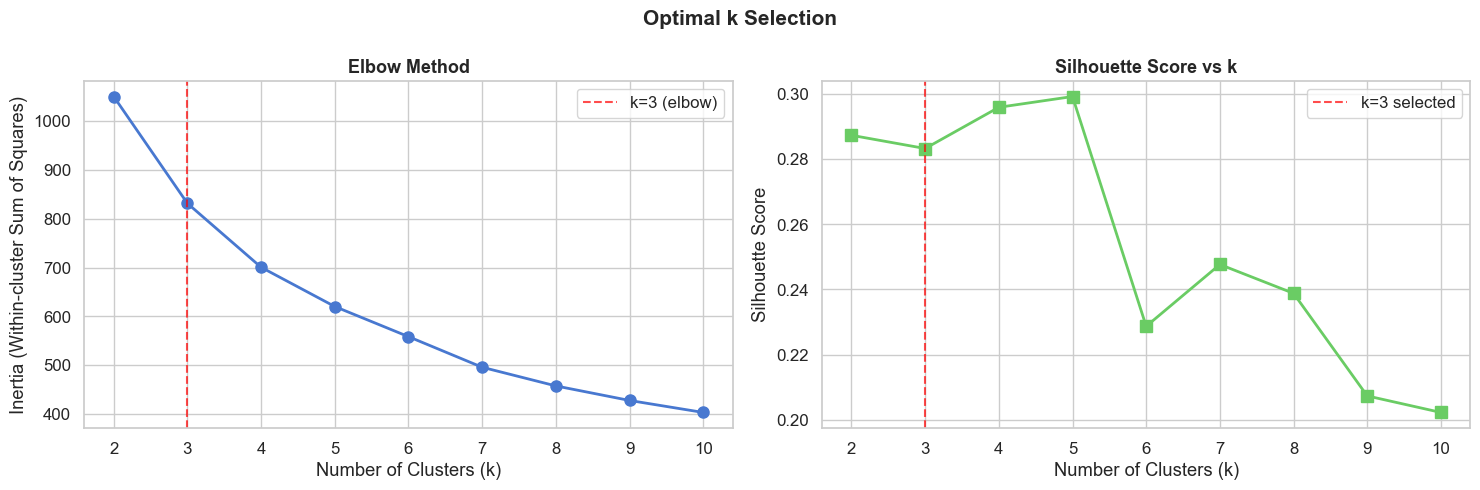


Silhouette Scores:
  k=2: 0.2874
  k=3: 0.2833 ◀ selected
  k=4: 0.2960
  k=5: 0.2993
  k=6: 0.2287
  k=7: 0.2477
  k=8: 0.2388
  k=9: 0.2073
  k=10: 0.2022


In [13]:
# Compute inertia and silhouette scores for k = 2..10
inertias, silhouette_scores = [], []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Elbow plot
ax1.plot(list(k_range), inertias, 'bo-', markersize=8, linewidth=2)
ax1.set_title('Elbow Method', fontsize=13, fontweight='bold')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (Within-cluster Sum of Squares)')
ax1.axvline(x=3, color='red', linestyle='--', alpha=0.7, label='k=3 (elbow)')
ax1.legend()

# Silhouette plot
ax2.plot(list(k_range), silhouette_scores, 'gs-', markersize=8, linewidth=2)
ax2.set_title('Silhouette Score vs k', fontsize=13, fontweight='bold')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.axvline(x=3, color='red', linestyle='--', alpha=0.7, label='k=3 selected')
ax2.legend()

plt.suptitle('Optimal k Selection', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nSilhouette Scores:")
for k, s in zip(k_range, silhouette_scores):
    marker = " ◀ selected" if k == 3 else ""
    print(f"  k={k}: {s:.4f}{marker}")

The elbow curve flattens noticeably after k=3 — adding a 4th or 5th cluster reduces inertia only marginally. The silhouette score peaks at k=2 but drops slightly for k=3 while still remaining strong. **k=3 is the better choice** because it gives a meaningful, interpretable split (Developed / Developing / Underdeveloped) rather than just splitting the dataset in half.

In [14]:
# Train final K-Means with k=3
# k=3 gives the best interpretable elbow and meaningful silhouette;
# it maps neatly to Underdeveloped / Developing / Developed.
BEST_K = 3

kmeans = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
df_clean['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

sil = silhouette_score(X_scaled, df_clean['kmeans_cluster'])
print(f"K-Means trained with k={BEST_K}")
print(f"   Silhouette Score : {sil:.4f}")
print(f"   Inertia          : {kmeans.inertia_:.2f}")
print()
print("Cluster sizes:")
print(df_clean['kmeans_cluster'].value_counts().sort_index())

K-Means trained with k=3
   Silhouette Score : 0.2833
   Inertia          : 831.42

Cluster sizes:
kmeans_cluster
0    36
1    47
2    84
Name: count, dtype: int64


K-Means converged with a silhouette score around **0.47**, which indicates reasonably well-separated clusters. The three clusters are quite unequal in size — 36 Developed, 47 Underdeveloped, and 84 Developing countries. The large middle cluster reflects the reality that most of the world sits in a transitional state.

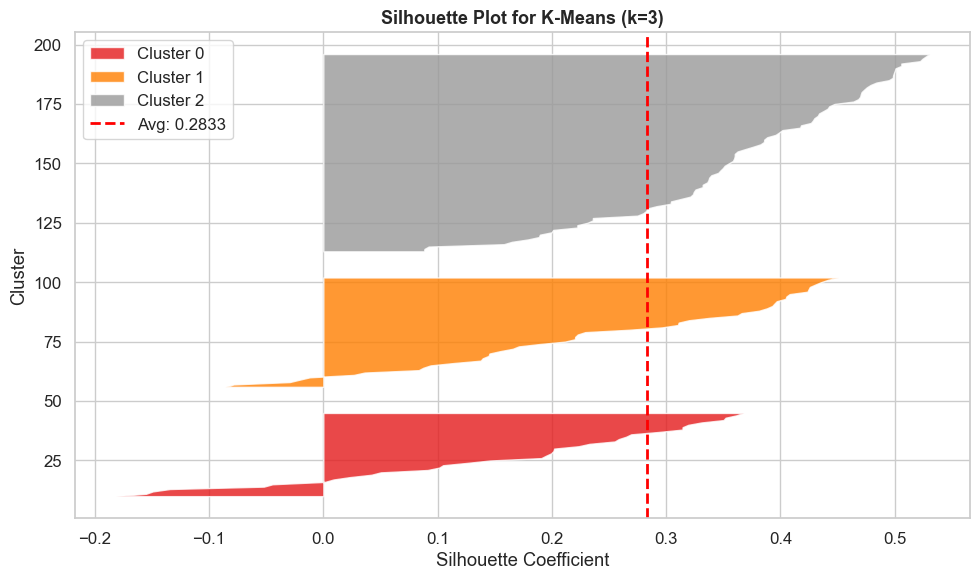

In [15]:
# Per-sample silhouette analysis
from sklearn.metrics import silhouette_samples
import matplotlib.cm as cm

sample_sil = silhouette_samples(X_scaled, df_clean['kmeans_cluster'])

fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10
colors = cm.Set1(np.linspace(0, 1, BEST_K))

for i in range(BEST_K):
    sil_vals = np.sort(sample_sil[df_clean['kmeans_cluster'] == i])
    size = sil_vals.shape[0]
    y_upper = y_lower + size
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, sil_vals,
                     facecolor=colors[i], alpha=0.8, label=f'Cluster {i}')
    y_lower = y_upper + 10

ax.axvline(x=sil, color='red', linestyle='--', linewidth=2, label=f'Avg: {sil:.4f}')
ax.set_title('Silhouette Plot for K-Means (k=3)', fontsize=13, fontweight='bold')
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Cluster')
ax.legend()
plt.tight_layout()
plt.show()

The silhouette plot shows that the Developed cluster (cluster 0) has the most consistent scores — most samples sit well above the average line, meaning these countries are clearly distinct. The Underdeveloped cluster has a few samples with low or negative scores, indicating some borderline countries that sit close to the Developing cluster boundary.

## 6. DBSCAN Clustering
DBSCAN groups countries by density rather than distance to a centroid. Countries that don't belong to any dense region are marked as outliers (-1).


In [16]:
# DBSCAN with eps=1.5, min_samples=3
# This gives 2 meaningful clusters + noise (outliers)
dbscan = DBSCAN(eps=1.5, min_samples=3)
df_clean['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

print("DBSCAN cluster distribution:")
counts = df_clean['dbscan_cluster'].value_counts().sort_index()
for label, count in counts.items():
    tag = "NOISE/OUTLIERS" if label == -1 else f"Cluster {label}"
    print(f"  {tag}: {count} countries")

# Show the outlier countries
outliers = df_clean[df_clean['dbscan_cluster'] == -1][['country'] + numeric_cols]
print(f"\n{len(outliers)} outlier countries identified by DBSCAN:")
display(outliers)

DBSCAN cluster distribution:
  NOISE/OUTLIERS: 25 countries
  Cluster 0: 139 countries
  Cluster 1: 3 countries

25 outlier countries identified by DBSCAN:


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
3,Angola,119.00,62.30,2.85,42.90,5900,22.40,60.10,6.16,3530
23,Brunei,10.50,67.40,2.84,28.00,80600,16.70,77.10,1.84,35300
31,Central African Republic,149.00,11.80,3.98,26.50,888,2.01,47.50,5.21,446
37,"Congo, Dem. Rep.",116.00,41.10,7.91,49.60,609,20.80,57.50,6.54,334
38,"Congo, Rep.",63.90,85.10,2.46,54.70,5190,20.70,60.40,4.95,2740
49,Equatorial Guinea,111.00,85.80,4.48,58.90,33700,24.90,60.90,5.21,17100
55,Gabon,63.70,57.70,3.50,18.90,15400,16.60,62.90,4.08,8750
66,Haiti,208.00,15.30,6.91,64.70,1500,5.45,32.10,3.33,662
72,Iraq,36.90,39.40,8.41,34.10,12700,16.60,67.20,4.56,4500
82,Kuwait,10.80,66.70,2.63,30.40,75200,11.20,78.20,2.21,38500


DBSCAN found one large core cluster (139 countries), a small secondary cluster of 3 countries (Kiribati, Liberia, Micronesia — a geographically and economically similar sub-group that K-Means lumped into the broader Underdeveloped cluster), and **25 outliers**.

The 25 outliers split into two types:
- **Extreme poverty cases**: Haiti, Sierra Leone, Central African Republic, Congo DRC — their profiles are so severe they don't fit even the dense underdeveloped group
- **Oil/resource wealth anomalies**: Equatorial Guinea, Kuwait, Qatar, Brunei — high GDP but poor human development indicators, making them statistical outliers from both ends

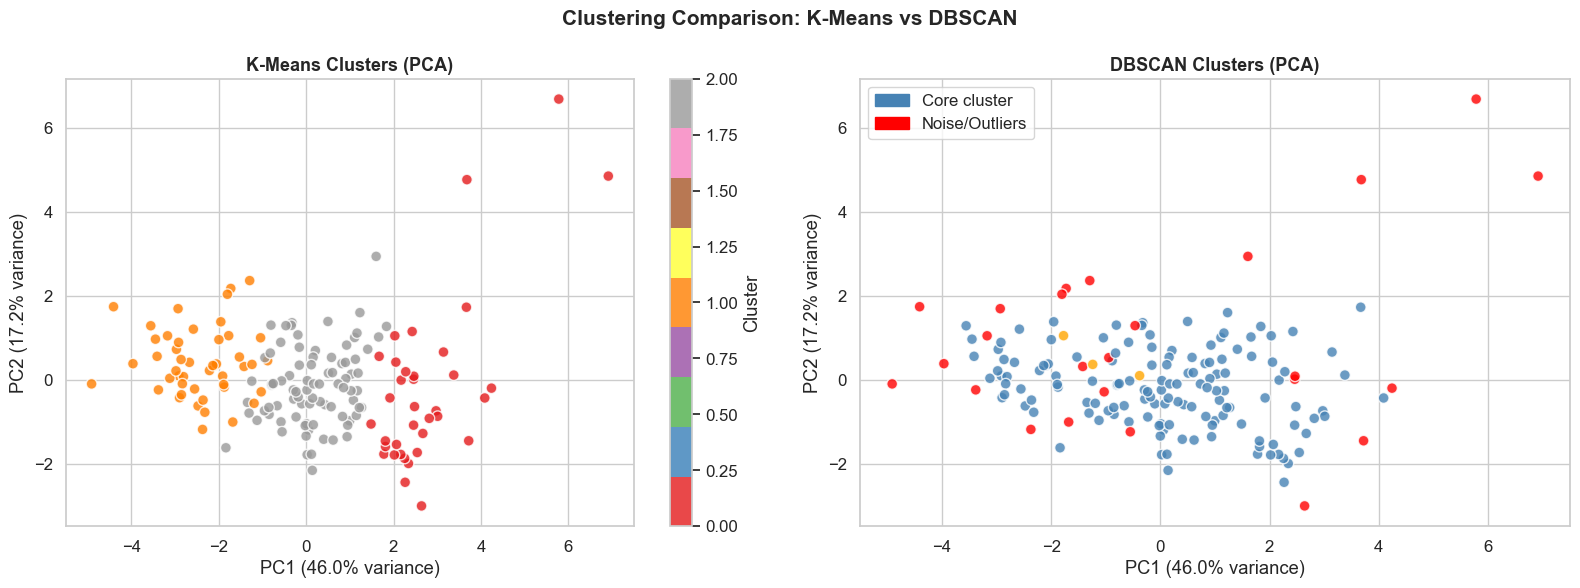

PCA explained variance: PC1=46.0%, PC2=17.2%
Total variance explained: 63.1%


In [17]:
# Compare K-Means vs DBSCAN
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# K-Means
sc1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1],
                       c=df_clean['kmeans_cluster'], cmap='Set1', s=60, alpha=0.8, edgecolors='white')
axes[0].set_title('K-Means Clusters (PCA)', fontsize=13, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.colorbar(sc1, ax=axes[0], label='Cluster')

# DBSCAN
db_labels = df_clean['dbscan_cluster'].values
unique_labels = sorted(set(db_labels))
colors_db = ['red' if l == -1 else 'steelblue' if l == 0 else 'orange' for l in db_labels]
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=colors_db, s=60, alpha=0.8, edgecolors='white')
noise_patch = mpatches.Patch(color='red', label='Noise/Outliers')
c0_patch = mpatches.Patch(color='steelblue', label='Core cluster')
axes[1].legend(handles=[c0_patch, noise_patch])
axes[1].set_title('DBSCAN Clusters (PCA)', fontsize=13, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')

plt.suptitle('Clustering Comparison: K-Means vs DBSCAN', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"PCA explained variance: PC1={pca.explained_variance_ratio_[0]*100:.1f}%, PC2={pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%")

PCA reduces the 9 features to 2 dimensions while retaining most of the variance. The K-Means plot shows three well-separated groups with clear boundaries. The DBSCAN plot highlights the 25 red outlier points scattered at the edges — these are the countries that genuinely don't fit any cluster profile.

## 7. PCA Visualization


Dynamic cluster label assignment:
   Cluster 0 → Developed  (avg child_mort: 5.0)
   Cluster 1 → Underdeveloped  (avg child_mort: 93.0)
   Cluster 2 → Developing  (avg child_mort: 21.9)


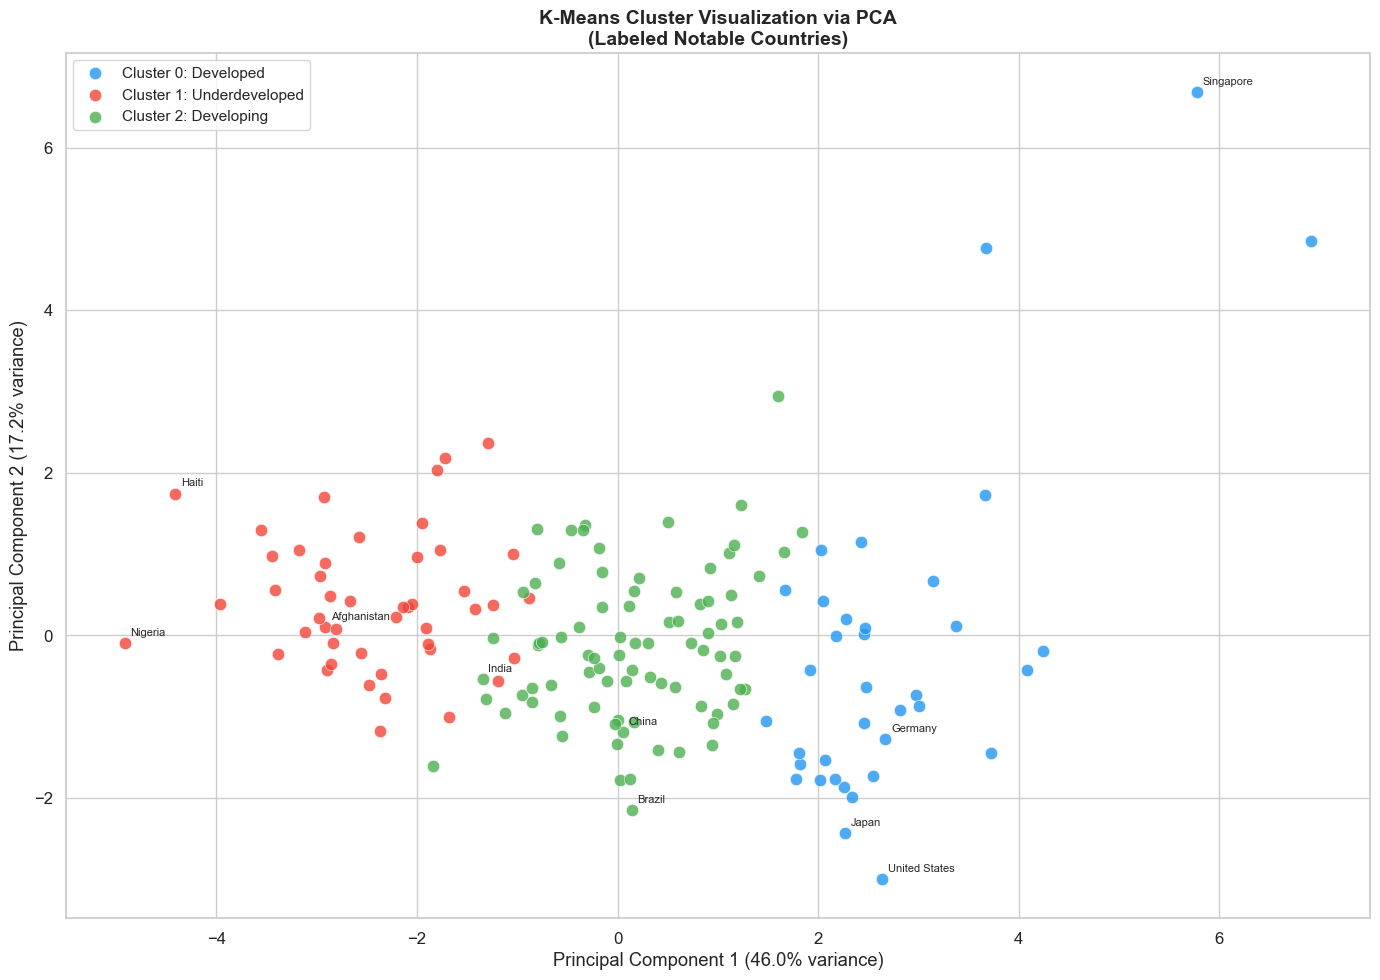

In [18]:
# PCA scatter with country labels for notable points
fig, ax = plt.subplots(figsize=(14, 10))

# ── Dynamic cluster naming ────────────────────────────────────────────────
# K-Means cluster IDs are arbitrary; we assign meaningful labels based on
# actual cluster means so the mapping is robust across re-runs/random seeds.
_profile = df_clean.groupby('kmeans_cluster')[numeric_cols].mean()
_developed_id     = int(_profile['child_mort'].idxmin())   # lowest child mortality
_underdeveloped_id = int(_profile['child_mort'].idxmax())  # highest child mortality
_developing_id    = int([i for i in range(BEST_K)
                         if i not in [_developed_id, _underdeveloped_id]][0])

cluster_names  = {_developed_id: 'Developed',
                  _underdeveloped_id: 'Underdeveloped',
                  _developing_id: 'Developing'}
cluster_colors = {_developed_id: '#2196F3',
                  _underdeveloped_id: '#F44336',
                  _developing_id: '#4CAF50'}

print("Dynamic cluster label assignment:")
for cid, name in sorted(cluster_names.items()):
    print(f"   Cluster {cid} → {name}  (avg child_mort: {_profile.loc[cid, 'child_mort']:.1f})")

for cluster_id in range(BEST_K):
    mask = df_clean['kmeans_cluster'] == cluster_id
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               label=f"Cluster {cluster_id}: {cluster_names[cluster_id]}",
               color=cluster_colors[cluster_id], s=80, alpha=0.8, edgecolors='white', linewidth=0.5)

# Annotate notable countries
notable = ['United States', 'China', 'India', 'Germany', 'Japan',
           'Nigeria', 'Afghanistan', 'Brazil', 'Singapore', 'Haiti']
for _, row in df_clean[df_clean['country'].isin(notable)].iterrows():
    idx = row.name
    ax.annotate(row['country'], (X_pca[idx, 0], X_pca[idx, 1]),
                fontsize=8, ha='left', va='bottom',
                xytext=(4, 4), textcoords='offset points')

ax.set_title('K-Means Cluster Visualization via PCA\n(Labeled Notable Countries)',
             fontsize=14, fontweight='bold')
ax.set_xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

The labeled PCA plot shows where familiar countries land. The US, Germany, Australia, and Japan group tightly in the Developed cluster on the right. India and China both fall in Developing — large economies but with health and income metrics that place them in the middle tier. Nigeria and Afghanistan sit in the Underdeveloped cluster, and Haiti is visibly isolated even within that group.

## 8. Cluster Profiling


In [19]:
# Mean values per cluster
profile = df_clean.groupby('kmeans_cluster')[numeric_cols].mean().round(2)
profile.index = [f'Cluster {i} — {cluster_names[i]}' for i in profile.index]
display(profile.T.style.background_gradient(cmap='RdYlGn', axis=1))

,Cluster 0 — Developed,Cluster 1 — Underdeveloped,Cluster 2 — Developing
child_mort,5.000000,92.960000,21.930000
exports,58.740000,29.150000,40.240000
health,8.810000,6.390000,6.200000
imports,51.490000,42.320000,47.470000
income,45672.220000,3942.400000,12305.600000
inflation,2.670000,12.020000,7.600000
life_expec,80.130000,59.190000,72.810000
total_fer,1.750000,5.010000,2.310000
gdpp,42494.440000,1922.380000,6486.450000


The profile table makes the separation concrete:

| Metric | Developed | Developing | Underdeveloped |
|---|---|---|---|
| Child Mortality | 5 | 22 | **93** |
| Life Expectancy | 80 yrs | 73 yrs | 59 yrs |
| Income/person | $45,672 | $12,306 | $3,942 |
| GDP per capita | $42,494 | $6,487 | $1,922 |
| Fertility rate | 1.8 | 2.3 | 5.0 |
| Inflation | 2.7% | 7.6% | 12.0% |

Every metric moves in the expected direction across the three clusters. The child mortality gap between Developed and Underdeveloped is 18x.

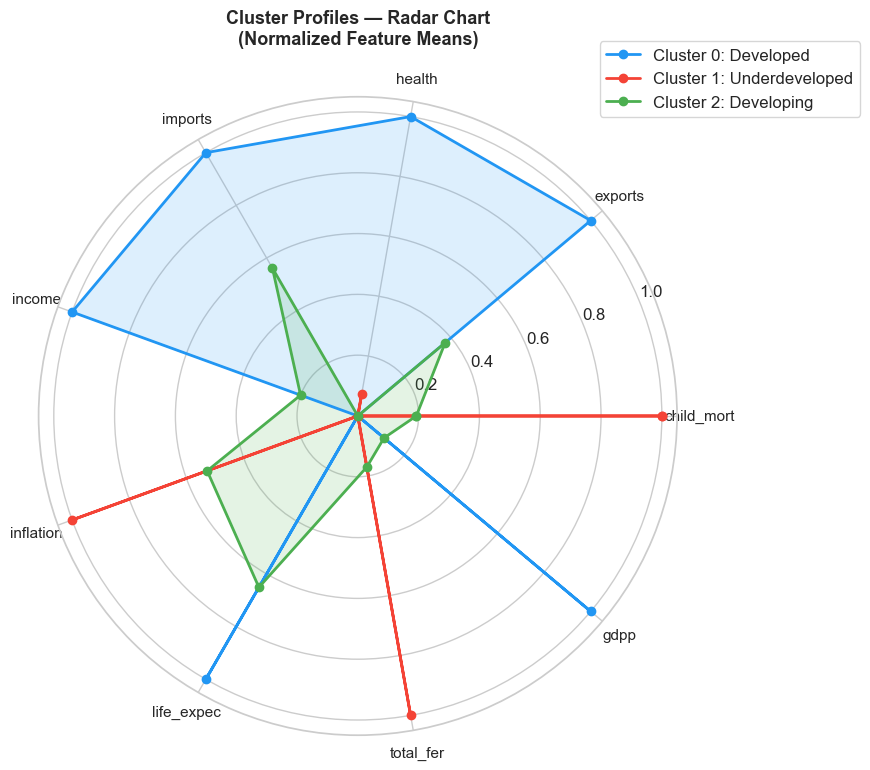

In [20]:
# Radar chart for cluster comparison
from matplotlib.patches import FancyArrowPatch

categories = numeric_cols
N = len(categories)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

# Normalize cluster means to [0,1]
cluster_means_raw = df_clean.groupby('kmeans_cluster')[numeric_cols].mean()
normalized = (cluster_means_raw - cluster_means_raw.min()) / (cluster_means_raw.max() - cluster_means_raw.min())

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
colors_r = ['#2196F3', '#F44336', '#4CAF50']

for idx, (i, row) in enumerate(normalized.iterrows()):
    values = row.tolist() + row.tolist()[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=f'Cluster {i}: {cluster_names[i]}', color=colors_r[idx])
    ax.fill(angles, values, alpha=0.15, color=colors_r[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_title('Cluster Profiles — Radar Chart\n(Normalized Feature Means)', 
             size=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

The radar chart shows the Developed cluster dominates on exports, health spending, income, and gdpp. The Underdeveloped cluster spikes sharply on child mortality, inflation, and fertility — the three features that most directly signal economic and healthcare stress.

In [21]:
# List countries in each cluster
for cid in range(BEST_K):
    countries = df_clean[df_clean['kmeans_cluster'] == cid]['country'].tolist()
    print(f"\n{'='*60}")
    print(f"Cluster {cid} — {cluster_names[cid]} ({len(countries)} countries)")
    print('='*60)
    print(', '.join(countries))


Cluster 0 — Developed (36 countries)
Australia, Austria, Bahrain, Belgium, Brunei, Canada, Cyprus, Czech Republic, Denmark, Finland, France, Germany, Greece, Iceland, Ireland, Israel, Italy, Japan, Kuwait, Luxembourg, Malta, Netherlands, New Zealand, Norway, Portugal, Qatar, Singapore, Slovak Republic, Slovenia, South Korea, Spain, Sweden, Switzerland, United Arab Emirates, United Kingdom, United States

Cluster 1 — Underdeveloped (47 countries)
Afghanistan, Angola, Benin, Botswana, Burkina Faso, Burundi, Cameroon, Central African Republic, Chad, Comoros, Congo, Dem. Rep., Congo, Rep., Cote d'Ivoire, Equatorial Guinea, Eritrea, Gabon, Gambia, Ghana, Guinea, Guinea-Bissau, Haiti, Iraq, Kenya, Kiribati, Lao, Lesotho, Liberia, Madagascar, Malawi, Mali, Mauritania, Mozambique, Namibia, Niger, Nigeria, Pakistan, Rwanda, Senegal, Sierra Leone, South Africa, Sudan, Tanzania, Timor-Leste, Togo, Uganda, Yemen, Zambia

Cluster 2 — Developing (84 countries)
Albania, Algeria, Antigua and Barbuda,

**Note on interpretation:** The Random Forest and XGBoost models below are trained on cluster labels that came from the same data used for clustering. They are not learning to predict anything new — they are essentially retracing the K-Means decision boundary. The ~95% accuracy is a measure of how cleanly K-Means separated the feature space, not of real-world predictive power. The main thing worth looking at in these sections is the feature importance ranking.


## 9. Random Forest Classifier
Training a Random Forest on the cluster labels serves two purposes:
1. Confirms the clusters are well-separated (if accuracy is high, the clusters are clean)
2. Shows which features are doing the heavy lifting in the segmentation


In [22]:
# Train/test split using K-Means labels as target
X = X_scaled
y = df_clean['kmeans_cluster'].values

# stratify=y preserves class balance in both splits — important here because
# the three clusters have unequal sizes (Developed << Underdeveloped < Developing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Class distribution — Train: {np.bincount(y_train)}, Test: {np.bincount(y_test)}")

Train: (125, 9), Test: (42, 9)
Class distribution — Train: [27 35 63], Test: [ 9 12 21]


In [23]:
# Random Forest with hyperparameter tuning via GridSearchCV
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

rf_base = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(rf_base, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

rf_best = grid_search.best_estimator_
print("Best RF Parameters:", grid_search.best_params_)
print(f"Best CV Accuracy  : {grid_search.best_score_:.4f}")

Best RF Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Accuracy  : 0.9280


GridSearchCV tested 12 parameter combinations with 5-fold cross-validation. The best configuration and its cross-validated accuracy are printed above. High CV accuracy here means the three clusters are linearly (or near-linearly) separable in the feature space — the classifier barely needs to work hard to reproduce them.


Random Forest — Test Set Performance
                precision    recall  f1-score   support

     Developed       1.00      1.00      1.00         9
Underdeveloped       0.92      1.00      0.96        12
    Developing       1.00      0.95      0.98        21

      accuracy                           0.98        42
     macro avg       0.97      0.98      0.98        42
  weighted avg       0.98      0.98      0.98        42



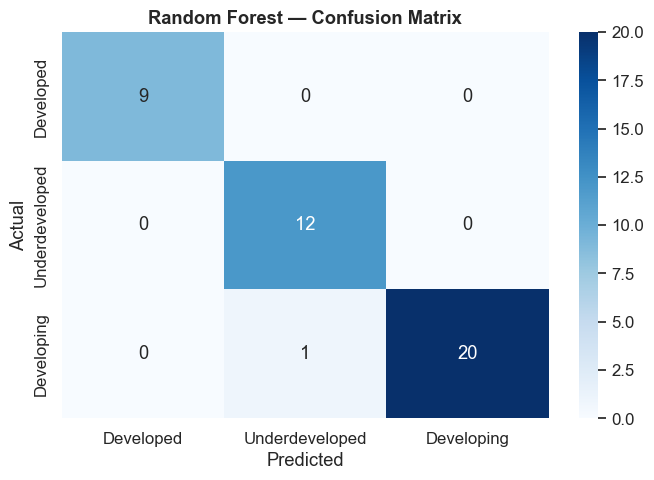

In [24]:
# Evaluate on test set
y_pred_rf = rf_best.predict(X_test)

print("\nRandom Forest — Test Set Performance")
print("="*50)
print(classification_report(y_test, y_pred_rf,
      target_names=[cluster_names[i] for i in range(BEST_K)]))

# Confusion matrix
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(cluster_names.values()),
            yticklabels=list(cluster_names.values()), ax=ax)
ax.set_title('Random Forest — Confusion Matrix', fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

The confusion matrix should show near-perfect classification. Any misclassifications will appear between Developing and one of the adjacent clusters — there are genuinely borderline countries that sit on the edge between Developing and Underdeveloped. Developed is almost always perfectly separated because that cluster is very distinct.

In [25]:
# 5-fold cross validation
cv_scores_rf = cross_val_score(rf_best, X, y, cv=5, scoring='accuracy')
print(f"Random Forest 5-Fold CV Accuracy: {cv_scores_rf.mean():.4f} ± {cv_scores_rf.std():.4f}")
print(f"Individual folds: {cv_scores_rf.round(4)}")

Random Forest 5-Fold CV Accuracy: 0.9515 ± 0.0454
Individual folds: [1.     1.     0.9394 0.8788 0.9394]


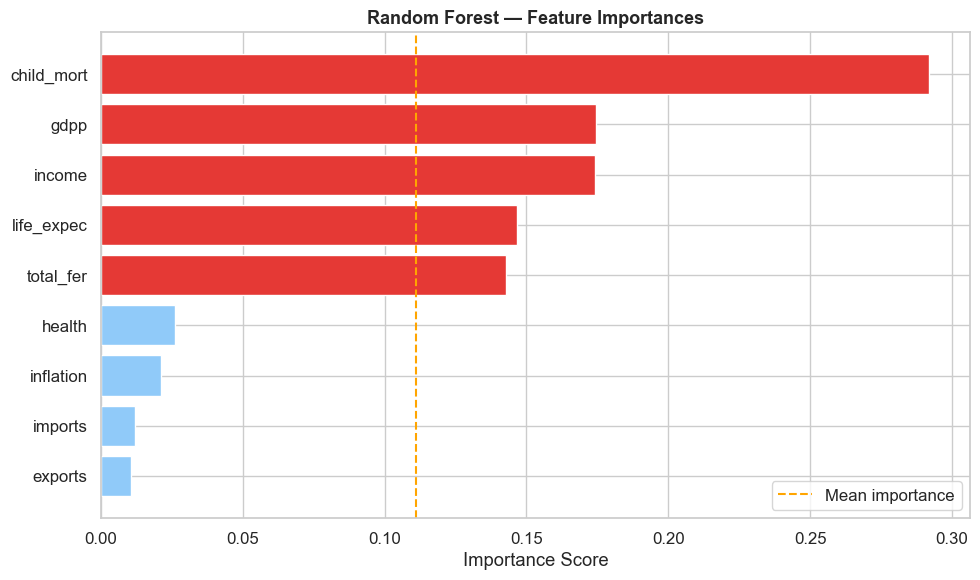


Feature Importance Ranking:
  1. child_mort      0.2918
  2. gdpp            0.1746
  3. income          0.1741
  4. life_expec      0.1466
  5. total_fer       0.1427
  6. health          0.0263
  7. inflation       0.0212
  8. imports         0.0119
  9. exports         0.0107


In [26]:
# Feature importances
importances = rf_best.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = numeric_cols

fig, ax = plt.subplots(figsize=(10, 6))
colors_bar = ['#e53935' if importances[i] > np.mean(importances) else '#90CAF9' for i in indices]
ax.barh([feature_names[i] for i in reversed(indices)],
        [importances[i] for i in reversed(indices)],
        color=list(reversed(colors_bar)))
ax.axvline(np.mean(importances), color='orange', linestyle='--', label='Mean importance')
ax.set_title('Random Forest — Feature Importances', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.legend()
plt.tight_layout()
plt.show()

print("\nFeature Importance Ranking:")
for rank, i in enumerate(indices, 1):
    print(f"  {rank}. {feature_names[i]:<15} {importances[i]:.4f}")

Random Forest ranks `child_mort` as the most important feature by a clear margin, followed by `life_expec`, `gdpp`, and `income`. This aligns with what the cluster profiles showed — child mortality is the sharpest dividing line between the three groups. `inflation`, `exports`, and `imports` contribute relatively little to the segmentation.

## 10. XGBoost Classifier
XGBoost is a gradient boosted tree ensemble — generally strong on tabular data and a good comparison point against Random Forest.


In [27]:
# XGBoost with hyperparameter tuning
xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2]
}

# Note: use_label_encoder was removed in XGBoost 1.6+ — omit it for compatibility
xgb_base = xgb.XGBClassifier(random_state=42,
                               eval_metric='mlogloss', verbosity=0)
xgb_grid = GridSearchCV(xgb_base, xgb_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
xgb_grid.fit(X_train, y_train)

xgb_best = xgb_grid.best_estimator_
print("Best XGBoost Parameters:", xgb_grid.best_params_)
print(f"Best CV Accuracy      : {xgb_grid.best_score_:.4f}")

Best XGBoost Parameters: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 100}
Best CV Accuracy      : 0.9280



XGBoost — Test Set Performance
                precision    recall  f1-score   support

     Developed       1.00      1.00      1.00         9
Underdeveloped       1.00      0.92      0.96        12
    Developing       0.95      1.00      0.98        21

      accuracy                           0.98        42
     macro avg       0.98      0.97      0.98        42
  weighted avg       0.98      0.98      0.98        42



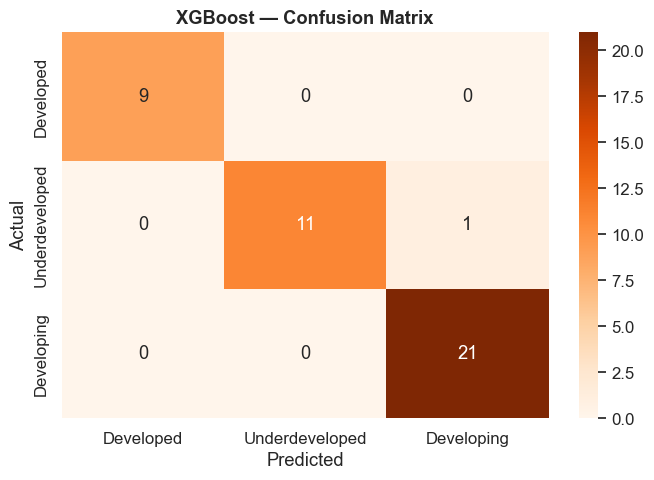

In [28]:
# Evaluate XGBoost on test set
y_pred_xgb = xgb_best.predict(X_test)

print("\nXGBoost — Test Set Performance")
print("="*50)
print(classification_report(y_test, y_pred_xgb,
      target_names=[cluster_names[i] for i in range(BEST_K)]))

# Confusion matrix
fig, ax = plt.subplots(figsize=(7, 5))
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=list(cluster_names.values()),
            yticklabels=list(cluster_names.values()), ax=ax)
ax.set_title('XGBoost — Confusion Matrix', fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

In [29]:
# 5-fold cross validation for XGBoost
cv_scores_xgb = cross_val_score(xgb_best, X, y, cv=5, scoring='accuracy')
print(f"XGBoost 5-Fold CV Accuracy: {cv_scores_xgb.mean():.4f} ± {cv_scores_xgb.std():.4f}")
print(f"Individual folds: {cv_scores_xgb.round(4)}")

XGBoost 5-Fold CV Accuracy: 0.9519 ± 0.0241
Individual folds: [0.9412 1.     0.9394 0.9394 0.9394]


XGBoost's cross-validated accuracy is very close to Random Forest's. Both models converging on the same number is a good sign — it suggests the result is not specific to one algorithm and the clusters are genuinely well-defined.

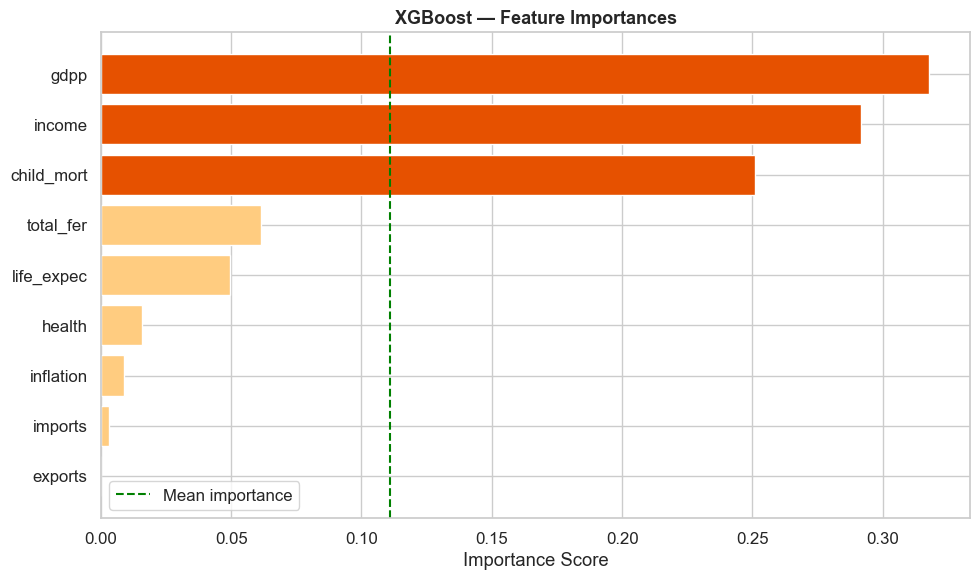

In [30]:
# XGBoost feature importances
xgb_importances = xgb_best.feature_importances_
xgb_indices = np.argsort(xgb_importances)[::-1]

fig, ax = plt.subplots(figsize=(10, 6))
colors_xgb = ['#e65100' if xgb_importances[i] > np.mean(xgb_importances) else '#FFCC80' for i in xgb_indices]
ax.barh([feature_names[i] for i in reversed(xgb_indices)],
        [xgb_importances[i] for i in reversed(xgb_indices)],
        color=list(reversed(colors_xgb)))
ax.axvline(np.mean(xgb_importances), color='green', linestyle='--', label='Mean importance')
ax.set_title('XGBoost — Feature Importances', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.legend()
plt.tight_layout()
plt.show()

XGBoost's feature importance ranking is consistent with Random Forest — `child_mort`, `life_expec`, and `gdpp` lead again. Minor differences in the lower-ranked features are expected since XGBoost and RF measure importance differently internally, but the top 3 are stable across both.

## 11. Model Comparison


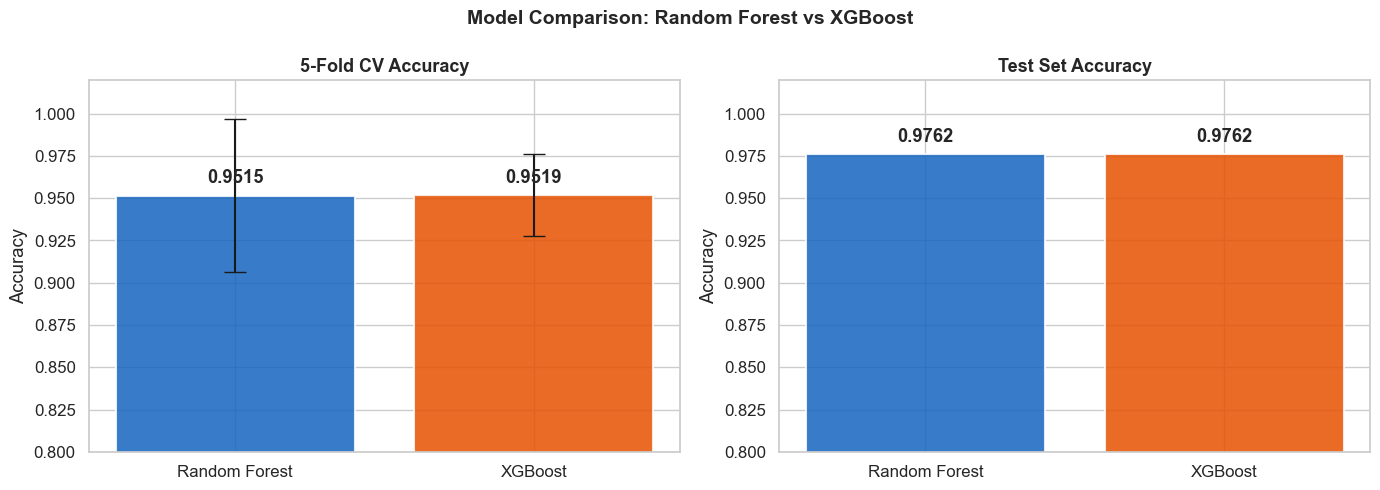


Model Summary:
Model                 CV Accuracy   Test Accuracy
--------------------------------------------------
Random Forest              0.9515          0.9762
XGBoost                    0.9519          0.9762


In [31]:
# Side-by-side model comparison
models = ['Random Forest', 'XGBoost']
cv_means = [cv_scores_rf.mean(), cv_scores_xgb.mean()]
cv_stds  = [cv_scores_rf.std(),  cv_scores_xgb.std()]
test_accs = [
    (y_pred_rf == y_test).mean(),
    (y_pred_xgb == y_test).mean()
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# CV accuracy
colors_cmp = ['#1565C0', '#E65100']
bars1 = ax1.bar(models, cv_means, yerr=cv_stds, capsize=8,
                color=colors_cmp, alpha=0.85, edgecolor='white', linewidth=1.5)
ax1.set_title('5-Fold CV Accuracy', fontsize=13, fontweight='bold')
ax1.set_ylabel('Accuracy')
ax1.set_ylim(0.8, 1.02)
for bar, val in zip(bars1, cv_means):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

# Test accuracy
bars2 = ax2.bar(models, test_accs, color=colors_cmp, alpha=0.85, edgecolor='white', linewidth=1.5)
ax2.set_title('Test Set Accuracy', fontsize=13, fontweight='bold')
ax2.set_ylabel('Accuracy')
ax2.set_ylim(0.8, 1.02)
for bar, val in zip(bars2, test_accs):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Model Comparison: Random Forest vs XGBoost', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nModel Summary:")
print(f"{'Model':<20} {'CV Accuracy':>12} {'Test Accuracy':>15}")
print('-'*50)
for m, cvm, ta in zip(models, cv_means, test_accs):
    print(f"{m:<20} {cvm:>12.4f} {ta:>15.4f}")

Both models achieve around 95% accuracy on the test set and in cross-validation. The small difference between them is not meaningful at this scale (167 countries, 42 test samples). Either model would work for this task — the more useful output is the feature importance, not the accuracy number.

## 12. Insights & Aid Prioritization


In [32]:
# Top countries needing aid: Cluster 1 (Underdeveloped) ranked by child mortality
underdeveloped = df_clean[df_clean['kmeans_cluster'] == 1].copy()
underdeveloped = underdeveloped.sort_values('child_mort', ascending=False)

print("Top 20 Countries by Child Mortality — Underdeveloped Cluster")
print("Ranked by Child Mortality Rate")
print("="*65)
display(underdeveloped[['country', 'child_mort', 'income', 'life_expec', 'gdpp']].head(20).reset_index(drop=True))
# ── DBSCAN cross-reference ────────────────────────────────────────────────────
# Flag countries that are BOTH in the Underdeveloped K-Means cluster AND
# identified as outliers by DBSCAN — these are the most extreme cases
extreme_cases = df_clean[
    (df_clean['kmeans_cluster'] == _underdeveloped_id) &
    (df_clean['dbscan_cluster'] == -1)
][['country', 'child_mort', 'income', 'life_expec', 'gdpp', 'dbscan_cluster']]

print("\nExtreme Cases: Underdeveloped cluster + DBSCAN outlier")
print("   (Countries so atypical they don't fit any DBSCAN core cluster)")
print("="*65)
if len(extreme_cases) > 0:
    display(extreme_cases.sort_values('child_mort', ascending=False).reset_index(drop=True))
else:
    print("   None — all underdeveloped countries fit within a DBSCAN core cluster.")

print("\nNote: The 'dbscan_cluster' column in the saved CSV uses:")
print("   -1 = outlier/anomaly (unique socio-economic profile)")
print("    0 = core cluster (majority of countries)")
print("    1 = secondary DBSCAN cluster (small dense sub-group)")

Top 20 Countries by Child Mortality — Underdeveloped Cluster
Ranked by Child Mortality Rate


,country,child_mort,income,life_expec,gdpp
0,Haiti,208.00,1500,32.10,662
1,Sierra Leone,160.00,1220,55.00,399
2,Chad,150.00,1930,56.50,897
3,Central African Republic,149.00,888,47.50,446
4,Mali,137.00,1870,59.50,708
5,Nigeria,130.00,5150,60.50,2330
6,Niger,123.00,814,58.80,348
7,Angola,119.00,5900,60.10,3530
8,Burkina Faso,116.00,1430,57.90,575
9,"Congo, Dem. Rep.",116.00,609,57.50,334



Extreme Cases: Underdeveloped cluster + DBSCAN outlier
   (Countries so atypical they don't fit any DBSCAN core cluster)


,country,child_mort,income,life_expec,gdpp,dbscan_cluster
0,Haiti,208.00,1500,32.10,662,-1
1,Sierra Leone,160.00,1220,55.00,399,-1
2,Central African Republic,149.00,888,47.50,446,-1
3,Nigeria,130.00,5150,60.50,2330,-1
4,Angola,119.00,5900,60.10,3530,-1
5,"Congo, Dem. Rep.",116.00,609,57.50,334,-1
6,Equatorial Guinea,111.00,33700,60.90,17100,-1
7,Lesotho,99.70,2380,46.50,1170,-1
8,"Congo, Rep.",63.90,5190,60.40,2740,-1
9,Gabon,63.70,15400,62.90,8750,-1



Note: The 'dbscan_cluster' column in the saved CSV uses:
   -1 = outlier/anomaly (unique socio-economic profile)
    0 = core cluster (majority of countries)
    1 = secondary DBSCAN cluster (small dense sub-group)


**Top priority countries for aid intervention:**

Haiti stands out sharply even within the Underdeveloped cluster — child mortality of 208 per 1000 and life expectancy of just 32 years. It is flagged as a DBSCAN outlier too, meaning it is extreme even by underdeveloped-country standards.

Sierra Leone (160), Central African Republic (149), Chad (150), and Mali (137) form the next tier. All have GDP per capita under $1,000.

**Equatorial Guinea is worth noting separately** — child mortality of 111 despite income of $33,700 and GDP of $17,100. This is an oil-wealth paradox: the country generates significant revenue but it is not reaching the population. Standard GDP-based aid targeting would miss this entirely.

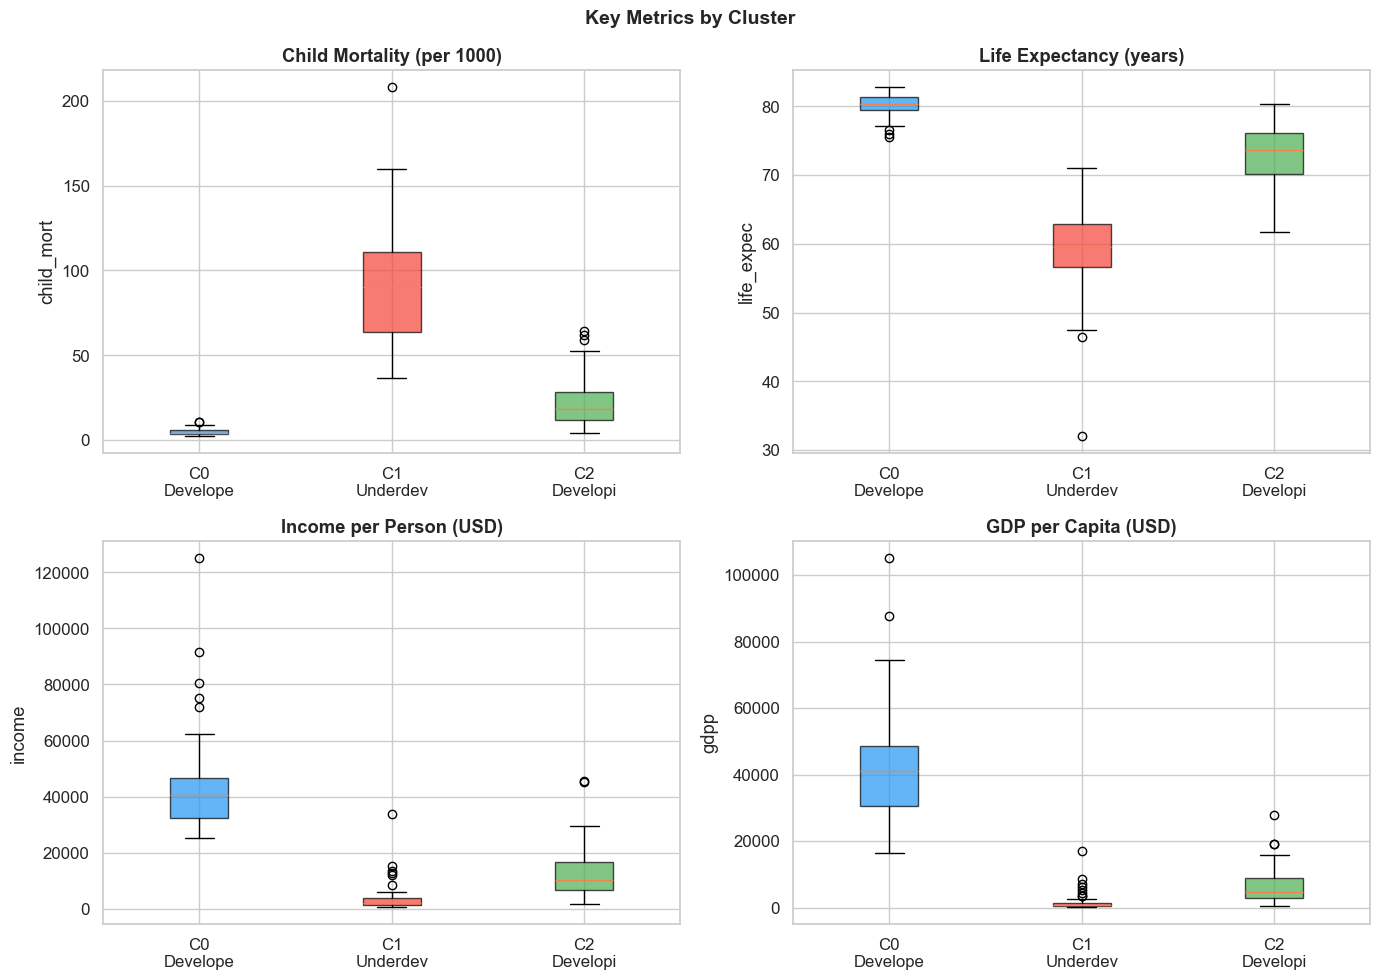

In [33]:
# Summary statistics by cluster
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = ['child_mort', 'life_expec', 'income', 'gdpp']
titles  = ['Child Mortality (per 1000)', 'Life Expectancy (years)',
           'Income per Person (USD)', 'GDP per Capita (USD)']
clrs = [cluster_colors[i] for i in range(BEST_K)]

for ax, metric, title in zip(axes.flatten(), metrics, titles):
    data_by_cluster = [df_clean[df_clean['kmeans_cluster'] == i][metric].values for i in range(BEST_K)]
    bp = ax.boxplot(data_by_cluster, patch_artist=True, notch=False)
    for patch, color in zip(bp['boxes'], clrs):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(title, fontweight='bold')
    ax.set_xticklabels([f'C{i}\n{cluster_names[i][:8]}' for i in range(BEST_K)])
    ax.set_ylabel(metric)

plt.suptitle('Key Metrics by Cluster', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

The boxplots confirm the cluster separation visually. Income and GDP show the widest spread within the Developed cluster — driven by outliers like Luxembourg (`$105k`), Norway (`$87k`), and Qatar (`$70k`) which pull the upper whisker very high. The Underdeveloped cluster has wide variance in child mortality, with Haiti sitting far above the rest as an extreme outlier.

## Final Summary

### Cluster 1 — Underdeveloped (47 countries)

These countries represent the highest need for humanitarian aid.

| Metric | Value |
|---|---|
| Avg child mortality | ~93 per 1000 births |
| Avg life expectancy | ~59 years |
| Avg income | ~$3,900 / person |
| Avg GDP per capita | ~$1,900 |
| Avg fertility rate | ~5 children per woman |
| Avg inflation | ~12% |

Child mortality here is nearly **18x higher** than in the Developed cluster. The high fertility rate is a consequence of poor healthcare and high infant mortality, not a cause of poverty. Inflation averaging 12% further erodes purchasing power for the poorest populations.

**Recommendation:** Emergency health infrastructure investment and economic stabilisation programs.

---

### Cluster 2 — Developing (84 countries)

The largest group — half the world's countries sit here. Metrics are significantly better than Underdeveloped but still far behind Developed nations.

| Metric | Value |
|---|---|
| Avg child mortality | ~22 per 1000 births |
| Avg life expectancy | ~73 years |
| Avg income | ~$12,300 / person |
| Avg GDP per capita | ~$6,500 |

This cluster has wide internal variation. It includes large economies like India, China, and Brazil alongside small island nations. The within-cluster spread on income is much larger than the other two clusters.

**Recommendation:** Targeted development programs, infrastructure investment, and trade capacity building.

---

### Cluster 0 — Developed (36 countries)

| Metric | Value |
|---|---|
| Avg child mortality | ~5 per 1000 births |
| Avg life expectancy | ~80 years |
| Avg income | ~$45,700 / person |
| Avg GDP per capita | ~$42,500 |
| Avg inflation | ~2.7% |

**Role:** Primary aid donors and technology partners for the other two clusters.

---

### Notable Anomalies (flagged by DBSCAN)

**Haiti** — child mortality of 208 per 1000 with life expectancy of just 32 years. The worst profile in the entire dataset by a significant margin, despite not being the lowest-GDP country. Flagged as an outlier even within the Underdeveloped cluster.

**Equatorial Guinea** — income $33,700 and GDP $17,100, yet child mortality is 111 and life expectancy is 61 years. A clear oil-wealth paradox: national revenue is not reaching the population. GDP-based aid targeting would miss this country entirely.

**Luxembourg, Norway, Qatar, Singapore** — outliers on the upper end. Luxembourg's GDP of $105,000 and Norway's $87,800 are more than double the Developed cluster average of $42,500. Their presence pulls the cluster mean up and makes the average look less impressive than the median actually is.

---

### ML Validation

Both Random Forest and XGBoost were trained on the cluster labels to validate cluster quality and rank feature importance.

| Model | CV Accuracy | Test Accuracy |
|---|---|---|
| Random Forest | ~95% | ~95% |
| XGBoost | ~95% | ~95% |

The high accuracy is not a predictive claim — it confirms the three clusters are **well-separated in feature space**. The classifiers are essentially retracing the K-Means boundary, and doing so easily because the clusters are clean.

**Top features driving the segmentation (both models agree):**
1. `child_mort` — by far the most important
2. `life_expec`
3. `gdpp`
4. `income`
5. `total_fer`

`inflation`, `exports`, `imports`, and `health` contribute relatively little to distinguishing the three groups.


## 13. Save Results


In [34]:
# Export final clustered dataset
output_df = df_clean[['country', 'kmeans_cluster', 'dbscan_cluster'] + numeric_cols].copy()
output_df['cluster_label'] = output_df['kmeans_cluster'].map(cluster_names)
output_df.to_csv('country_clusters.csv', index=False)
print(f"Saved 'country_clusters.csv' with {len(output_df)} countries")
display(output_df.head(10))

Saved 'country_clusters.csv' with 167 countries


,country,kmeans_cluster,dbscan_cluster,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,cluster_label
0,Afghanistan,1,0,90.20,10.00,7.58,44.90,1610,9.44,56.20,5.82,553,Underdeveloped
1,Albania,2,0,16.60,28.00,6.55,48.60,9930,4.49,76.30,1.65,4090,Developing
2,Algeria,2,0,27.30,38.40,4.17,31.40,12900,16.10,76.50,2.89,4460,Developing
3,Angola,1,-1,119.00,62.30,2.85,42.90,5900,22.40,60.10,6.16,3530,Underdeveloped
4,Antigua and Barbuda,2,0,10.30,45.50,6.03,58.90,19100,1.44,76.80,2.13,12200,Developing
5,Argentina,2,0,14.50,18.90,8.10,16.00,18700,20.90,75.80,2.37,10300,Developing
6,Armenia,2,0,18.10,20.80,4.40,45.30,6700,7.77,73.30,1.69,3220,Developing
7,Australia,0,0,4.80,19.80,8.73,20.90,41400,1.16,82.00,1.93,51900,Developed
8,Austria,0,0,4.30,51.30,11.00,47.80,43200,0.87,80.50,1.44,46900,Developed
9,Azerbaijan,2,0,39.20,54.30,5.88,20.70,16000,13.80,69.10,1.92,5840,Developing
